# LAB12 — Hartëzimi i Fushës Magnetike

**Emri i studentit:** Erik Cupi  
**Lënda:** Hyrje në Laborator  
**Tema:** Hartëzimi i Fushës Magnetike  

Ky raport paraqet matjen dhe vizualizimin e fushës magnetike në një rrjetë 2D. Matjet mund të bëhen me magnetometrin e telefonit dhe më pas të përpunohen në Python. Në këtë notebook përdoren të dhëna shembull të krijuara me Python, që kodi të ekzekutohet me sukses edhe kur skedarët CSV nuk janë ende të vendosur në folder.

## 1. Qëllimi

Qëllimi i laboratorit është të matet fusha magnetike në pika të ndryshme të hapësirës dhe të ndërtohet një hartë 2D e intensitetit të saj. Fusha magnetike matet përmes komponentëve $B_x$, $B_y$ dhe $B_z$, ndërsa intensiteti total llogaritet me formulën:

$$B = \sqrt{B_x^2 + B_y^2 + B_z^2}$$

Në këtë mënyrë mund të shihet se ku fusha magnetike është më e madhe dhe si ndryshon ajo pranë një magneti.

In [1]:
# Importimi i bibliotekave kryesore
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sigurohemi që figurat të shfaqen brenda notebook-ut
%matplotlib inline

# Krijojmë folderët bazë
Path("data").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)

print("Bibliotekat u importuan me sukses.")

Bibliotekat u importuan me sukses.


## 4. Krijimi i të dhënave shembull

Kodi më poshtë krijon të dhëna shembull për sfondin magnetik, matjen 1D dhe hartën 2D. Kjo bëhet që notebook-u të punojë pa gabime edhe nëse matjet reale nuk janë eksportuar ende nga telefoni. Kur të kesh matjet reale, mjafton të zëvendësosh CSV-të në folderin `data/`.

In [2]:
# Gjenerator për rezultate të riprodhueshme
rng = np.random.default_rng(12)

# 1) Të dhënat e sfondit magnetik për 60 sekonda
n_bg = 60
time_s = np.arange(n_bg)
Bx_bg = 22 + rng.normal(0, 0.5, n_bg)
By_bg = -6 + rng.normal(0, 0.4, n_bg)
Bz_bg = 38 + rng.normal(0, 0.6, n_bg)

df_bg = pd.DataFrame({
    "time_s": time_s,
    "Bx_uT": Bx_bg,
    "By_uT": By_bg,
    "Bz_uT": Bz_bg
})
df_bg.to_csv("data/B_background.csv", index=False)

# 2) Të dhënat 1D pranë magnetit
x_1d = np.array([2, 4, 6, 8, 10, 12, 14, 16], dtype=float)
y_1d = np.zeros_like(x_1d)
extra = 900 / (x_1d + 1.5)**3  # rënie e përafërt me largësinë

df_1d = pd.DataFrame({
    "x_cm": x_1d,
    "y_cm": y_1d,
    "Bx_uT": 22 + extra + rng.normal(0, 0.7, len(x_1d)),
    "By_uT": -6 + 0.25 * extra + rng.normal(0, 0.5, len(x_1d)),
    "Bz_uT": 38 + 0.45 * extra + rng.normal(0, 0.6, len(x_1d))
})
df_1d.to_csv("data/B_1D.csv", index=False)

# 3) Të dhënat 2D në rrjetë 9x9
coords = np.arange(-8, 9, 2, dtype=float)
rows = []
for y in coords:
    for x in coords:
        r = np.sqrt(x**2 + y**2 + 2.0**2)  # shtojmë 2 cm për të shmangur ndarjen me zero
        perturb = 1200 / (r + 1.0)**3
        rows.append({
            "x_cm": x,
            "y_cm": y,
            "Bx_uT": 22 + perturb * (x + 1) / (r + 1) + rng.normal(0, 0.5),
            "By_uT": -6 + perturb * (y + 1) / (r + 1) + rng.normal(0, 0.5),
            "Bz_uT": 38 + perturb + rng.normal(0, 0.6)
        })

df_map = pd.DataFrame(rows)
df_map.to_csv("data/B_map_2D.csv", index=False)

print("CSV-të shembull u krijuan me sukses në folderin data/.")
print(df_map.head())

CSV-të shembull u krijuan me sukses në folderin data/.
,   x_cm  y_cm      Bx_uT     By_uT      Bz_uT
,0  -8.0  -8.0  21.869513 -6.528837  38.922803
,1  -6.0  -8.0  21.919571 -6.922352  38.679466
,2  -4.0  -8.0  21.712509 -6.729453  39.125351
,3  -2.0  -8.0  21.695121 -6.723011  40.196408
,4   0.0  -8.0  22.434435 -7.519345  39.755632


## 5. Leximi i të dhënave dhe llogaritja e fushës totale

Në këtë pjesë lexohen të dhënat dhe llogaritet intensiteti total $B$. Më pas llogaritet mesatarja e sfondit magnetik dhe perturbimi $\Delta B$.

In [3]:
# Leximi i skedarëve CSV
background = pd.read_csv("data/B_background.csv")
df1 = pd.read_csv("data/B_1D.csv")
df = pd.read_csv("data/B_map_2D.csv")

# Funksion për llogaritjen e B totale
def calculate_B_total(dataframe):
    return np.sqrt(
        dataframe["Bx_uT"]**2 +
        dataframe["By_uT"]**2 +
        dataframe["Bz_uT"]**2
    )

background["B_uT"] = calculate_B_total(background)
df1["B_uT"] = calculate_B_total(df1)
df["B_uT"] = calculate_B_total(df)

B_background = background["B_uT"].mean()
df1["DeltaB_uT"] = df1["B_uT"] - B_background
df["DeltaB_uT"] = df["B_uT"] - B_background

print(f"Fusha mesatare e sfondit: {B_background:.2f} uT")
df.head()

Fusha mesatare e sfondit: 44.32 uT


,x_cm,y_cm,Bx_uT,By_uT,Bz_uT,B_uT,DeltaB_uT
0,-8.0,-8.0,21.869513,-6.528837,38.922803,45.120793,0.803540
1,-6.0,-8.0,21.919571,-6.922352,38.679466,44.994307,0.677054
2,-4.0,-8.0,21.712509,-6.729453,39.125351,45.249438,0.932186
3,-2.0,-8.0,21.695121,-6.723011,40.196408,46.169561,1.852309
4,0.0,-8.0,22.434435,-7.519345,39.755632,46.263968,1.946715


## 6. Analiza e sfondit magnetik

Matja e sfondit tregon sa e qëndrueshme është fusha kur telefoni nuk lëviz dhe nuk ka magnet shumë afër.

Statistikat e sfondit magnetik:
,count    60.000000
,mean     44.317252
,std       0.547209
,min      43.036497
,25%      43.956715
,50%      44.328608
,75%      44.655060
,max      46.009517
,Name: B_uT, dtype: float64


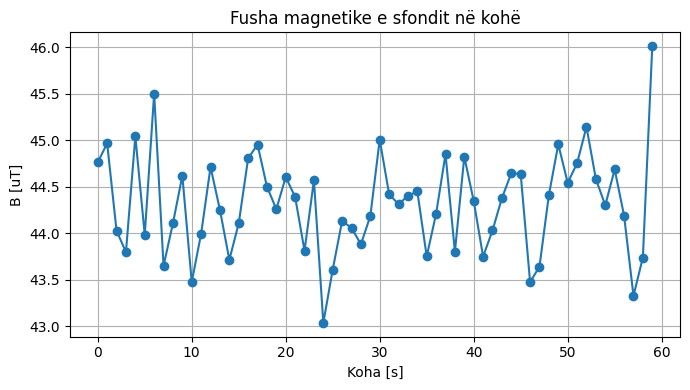

In [4]:
print("Statistikat e sfondit magnetik:")
print(background["B_uT"].describe())

plt.figure(figsize=(7, 4))
plt.plot(background["time_s"], background["B_uT"], marker="o")
plt.xlabel("Koha [s]")
plt.ylabel("B [uT]")
plt.title("Fusha magnetike e sfondit në kohë")
plt.grid(True)
plt.tight_layout()
plt.savefig("figs/B_background_time.png", dpi=150)
plt.show()

## 7. Analiza 1D pranë magnetit

Në këtë grafik shfaqet ndryshimi i fushës magnetike me largësinë nga magneti. Në përgjithësi, fusha bie kur largësia nga magneti rritet.

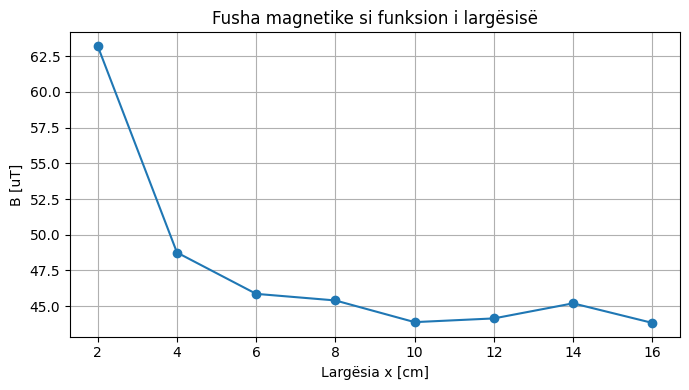

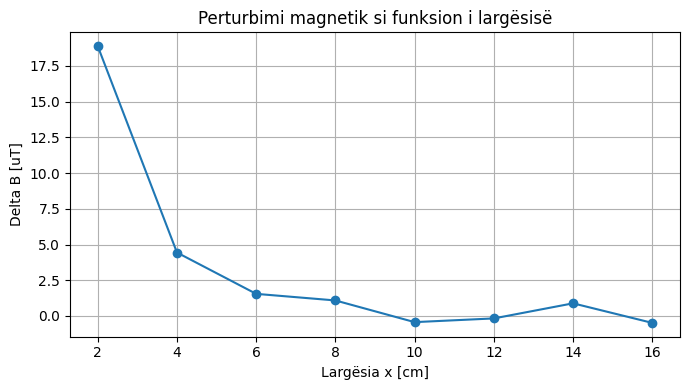

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(df1["x_cm"], df1["B_uT"], marker="o")
plt.xlabel("Largësia x [cm]")
plt.ylabel("B [uT]")
plt.title("Fusha magnetike si funksion i largësisë")
plt.grid(True)
plt.tight_layout()
plt.savefig("figs/B_vs_distance.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(df1["x_cm"], df1["DeltaB_uT"], marker="o")
plt.xlabel("Largësia x [cm]")
plt.ylabel("Delta B [uT]")
plt.title("Perturbimi magnetik si funksion i largësisë")
plt.grid(True)
plt.tight_layout()
plt.savefig("figs/DeltaB_vs_distance.png", dpi=150)
plt.show()

## 8. Harta 2D e fushës magnetike

Këtu ndërtohet harta 2D e fushës magnetike. Pikat me vlerë më të madhe tregojnë zonat ku ndikimi i magnetit është më i fortë.

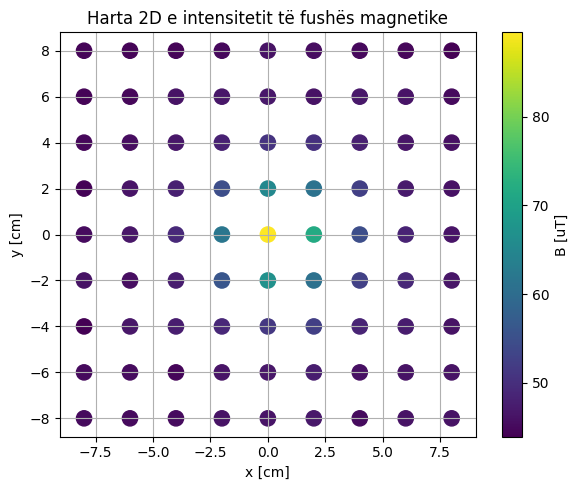

In [6]:
plt.figure(figsize=(6, 5))
plt.scatter(df["x_cm"], df["y_cm"], c=df["B_uT"], s=120)
plt.colorbar(label="B [uT]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Harta 2D e intensitetit të fushës magnetike")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig("figs/B_map_2D_scatter.png", dpi=150)
plt.show()

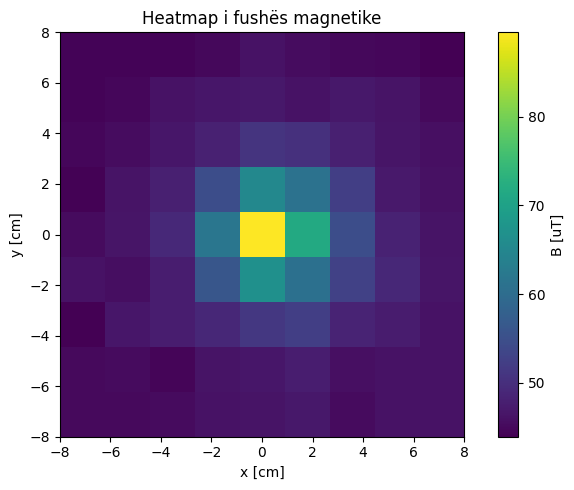

In [7]:
# Heatmap për B totale
B_grid = df.pivot(index="y_cm", columns="x_cm", values="B_uT")

plt.figure(figsize=(7, 5))
plt.imshow(
    B_grid.values,
    origin="lower",
    extent=[df["x_cm"].min(), df["x_cm"].max(), df["y_cm"].min(), df["y_cm"].max()],
    aspect="equal"
)
plt.colorbar(label="B [uT]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Heatmap i fushës magnetike")
plt.tight_layout()
plt.savefig("figs/B_map_2D_heatmap.png", dpi=150)
plt.show()

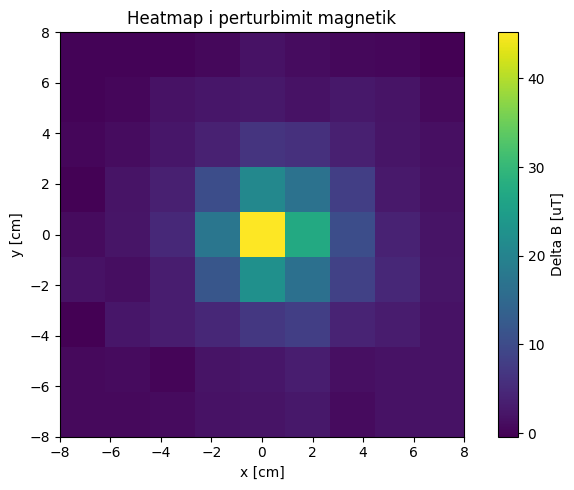

In [8]:
# Heatmap për Delta B
Delta_grid = df.pivot(index="y_cm", columns="x_cm", values="DeltaB_uT")

plt.figure(figsize=(7, 5))
plt.imshow(
    Delta_grid.values,
    origin="lower",
    extent=[df["x_cm"].min(), df["x_cm"].max(), df["y_cm"].min(), df["y_cm"].max()],
    aspect="equal"
)
plt.colorbar(label="Delta B [uT]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Heatmap i perturbimit magnetik")
plt.tight_layout()
plt.savefig("figs/DeltaB_map_2D_heatmap.png", dpi=150)
plt.show()

## 9. Tabela përmbledhëse

Tabela më poshtë përmbledh vlerat minimale, maksimale dhe mesatare të fushës magnetike për pjesët kryesore të eksperimentit.

In [9]:
summary = pd.DataFrame({
    "Eksperimenti": ["Sfondi", "Magneti 1D", "Harta 2D"],
    "B_min_uT": [background["B_uT"].min(), df1["B_uT"].min(), df["B_uT"].min()],
    "B_max_uT": [background["B_uT"].max(), df1["B_uT"].max(), df["B_uT"].max()],
    "B_mean_uT": [background["B_uT"].mean(), df1["B_uT"].mean(), df["B_uT"].mean()],
    "DeltaB_max_uT": [0, df1["DeltaB_uT"].max(), df["DeltaB_uT"].max()]
})

summary = summary.round(2)
summary

,Eksperimenti,B_min_uT,B_max_uT,B_mean_uT,DeltaB_max_uT
0,Sfondi,43.04,46.01,44.32,0.00
1,Magneti 1D,43.83,63.20,47.53,18.89
2,Harta 2D,43.92,89.50,48.77,45.18


## 11. Përfundim

Në këtë laborator u tregua se fusha magnetike mund të matet në pika të ndryshme dhe të paraqitet si hartë 2D. Përmes Python u llogarit intensiteti total i fushës magnetike, u zbrit sfondi magnetik dhe u ndërtuan grafikë për analizën 1D dhe 2D. Përfundimi kryesor është se edhe një sensor i thjeshtë si magnetometri i telefonit mund të japë të dhëna të dobishme për të kuptuar ndryshimin hapësinor të fushës magnetike, por interpretimi duhet bërë me kujdes.